# 01c L1B Waveform Component Detection

Purpose and scientific boundary:
- visualize waveform component detection on one or a few sweeps;
- explain how background subtraction, smoothing, and peak detection behave on individual pulses;
- compare waveform-derived component features against `good_snr` and `refh_snr`.

Important note:
- secondary peaks shown here are waveform-derived components, not georeferenced returns.

In [1]:
from pathlib import Path
import sys

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_casals_l1b_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "waveform_components.py").exists():
            return candidate
        if (candidate / "CASALS_L1B" / "waveform_components.py").exists():
            return candidate / "CASALS_L1B"
    raise FileNotFoundError("Could not locate CASALS_L1B directory from the current notebook working directory.")


CASALS_L1B_DIR = find_casals_l1b_root()
if str(CASALS_L1B_DIR) not in sys.path:
    sys.path.insert(0, str(CASALS_L1B_DIR))

from waveform_components import (
    build_record_index_grid,
    detect_components_1d,
    infer_waveform_record_axis,
    prepare_waveform_for_detection,
    read_optional_1d,
    read_waveform_records,
    require_dataset,
    safe_argmax_bin,
)

%matplotlib inline

H5_PATH = CASALS_L1B_DIR / "casals_h5_downloads" / "casals_l1b_20241118T171757_001_02.h5"
SELECTED_SWEEPS = [5000, 5001]
SELECTED_TRACKS_FOR_WAVEFORMS = [8, 16, 32, 64]
SWEEP_FOR_PLOTTING = SELECTED_SWEEPS[0]

DETECTION_CONFIG = {
    "background_mode": "minus_bg_mean",
    "clip_negative_after_background": True,
    "smoothing_method": "savgol",
    "smoothing_window": 7,
    "smoothing_polyorder": 2,
    "min_height_sigma": 3.0,
    "min_prominence_sigma": 3.0,
    "min_width_bins": 1.0,
    "max_width_bins": None,
    "min_distance_bins": 3,
    "max_components_per_pulse": 5,
}

assert H5_PATH.exists(), H5_PATH

In [2]:
with h5py.File(H5_PATH, "r") as h5:
    info = build_record_index_grid(h5)
    rx_ds = require_dataset(h5, "rx_waveform")
    tx_ds = require_dataset(h5, "tx_waveform")
    rx_record_axis = infer_waveform_record_axis(rx_ds, info.n_records)
    tx_record_axis = infer_waveform_record_axis(tx_ds, info.n_records)
    field_names = ["refh", "refh_amp", "refh_snr", "good_snr", "bg_mean", "bg_std", "refh_thres"]
    fields = {name: read_optional_1d(h5, name, info.n_records, dtype=(bool if name == "good_snr" else np.float64)) for name in field_names}

    def read_sweep_matrix(ds, record_axis, sweep_num):
        row = info.record_index_grid[int(sweep_num)]
        valid_tracks = np.flatnonzero(row >= 0)
        indices = row[valid_tracks]
        n_bins = int(ds.shape[1] if record_axis == 0 else ds.shape[0])
        matrix = np.full((info.n_tracks, n_bins), np.nan, dtype=np.float32)
        matrix[valid_tracks] = read_waveform_records(ds, record_axis, indices)
        return matrix

    tx_matrix = read_sweep_matrix(tx_ds, tx_record_axis, SWEEP_FOR_PLOTTING)
    rx_matrix = read_sweep_matrix(rx_ds, rx_record_axis, SWEEP_FOR_PLOTTING)

print("Loaded sweep:", SWEEP_FOR_PLOTTING)
print("tx_matrix shape:", tx_matrix.shape)
print("rx_matrix shape:", rx_matrix.shape)

Loaded sweep: 5000
tx_matrix shape: (256, 80)
rx_matrix shape: (256, 2728)


## Inspect One Sweep TX/RX Matrices

The plots below stay at the sweep/track organization level. They are diagnostic views of waveform storage, not point-cloud products.

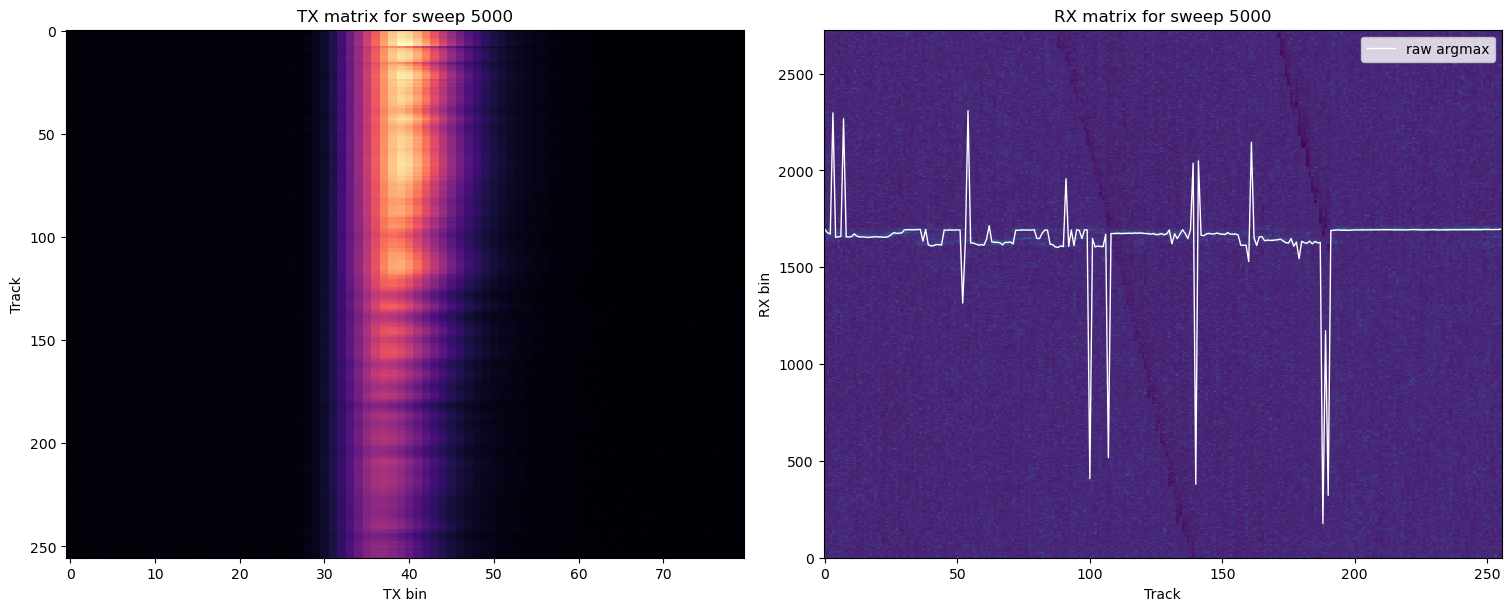

In [3]:
raw_argmax = np.array([safe_argmax_bin(row)[0] for row in rx_matrix], dtype=np.float64)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].imshow(tx_matrix, aspect="auto", cmap="magma", interpolation="nearest")
axes[0].set_title(f"TX matrix for sweep {SWEEP_FOR_PLOTTING}")
axes[0].set_xlabel("TX bin")
axes[0].set_ylabel("Track")

axes[1].imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
axes[1].plot(np.arange(info.n_tracks), raw_argmax, color="white", linewidth=1.0, label="raw argmax")
axes[1].set_title(f"RX matrix for sweep {SWEEP_FOR_PLOTTING}")
axes[1].set_xlabel("Track")
axes[1].set_ylabel("RX bin")
axes[1].legend(loc="upper right")
plt.show()

## Run `detect_components_1d` On Selected Tracks

This section applies the same peak detector used by `detect_waveform_components.py` to a few hand-picked tracks from one sweep.

In [4]:
selected_track_rows = []
selected_waveform_details = {}

for track_num in SELECTED_TRACKS_FOR_WAVEFORMS:
    pulse_index = int(info.record_index_grid[SWEEP_FOR_PLOTTING, track_num])
    y_raw = rx_matrix[track_num].astype(np.float64)
    cfg = dict(DETECTION_CONFIG)
    cfg["refh_thres"] = float(fields["refh_thres"][pulse_index])
    prepared = prepare_waveform_for_detection(
        y_raw=y_raw,
        bg_mean=float(fields["bg_mean"][pulse_index]),
        bg_std=float(fields["bg_std"][pulse_index]),
        config=cfg,
    )
    components = detect_components_1d(
        y_raw=y_raw,
        bg_mean=float(fields["bg_mean"][pulse_index]),
        bg_std=float(fields["bg_std"][pulse_index]),
        config=cfg,
    )
    selected_waveform_details[track_num] = {"prepared": prepared, "components": components, "pulse_index": pulse_index}
    selected_track_rows.append(
        {
            "track_num": track_num,
            "pulse_index": pulse_index,
            "refh_snr": float(fields["refh_snr"][pulse_index]),
            "good_snr": bool(fields["good_snr"][pulse_index]),
            "n_components": len(components),
            "main_peak_bin": components[0]["peak_bin"] if components else np.nan,
            "main_prominence": components[0]["prominence"] if components else np.nan,
            "main_width_bins": components[0]["width_bins"] if components else np.nan,
        }
    )

selected_track_summary = pd.DataFrame(selected_track_rows)
selected_track_summary

,track_num,pulse_index,refh_snr,good_snr,n_components,main_peak_bin,main_prominence,main_width_bins
0,8,1280001,3.593124,False,5,1657,945.277643,8.178415
1,16,1280002,3.774088,False,5,1654,920.761036,18.552627
2,32,1280004,7.508195,True,5,1694,1957.842483,7.425857
3,64,1280008,4.801882,False,5,1629,1370.365786,18.100434


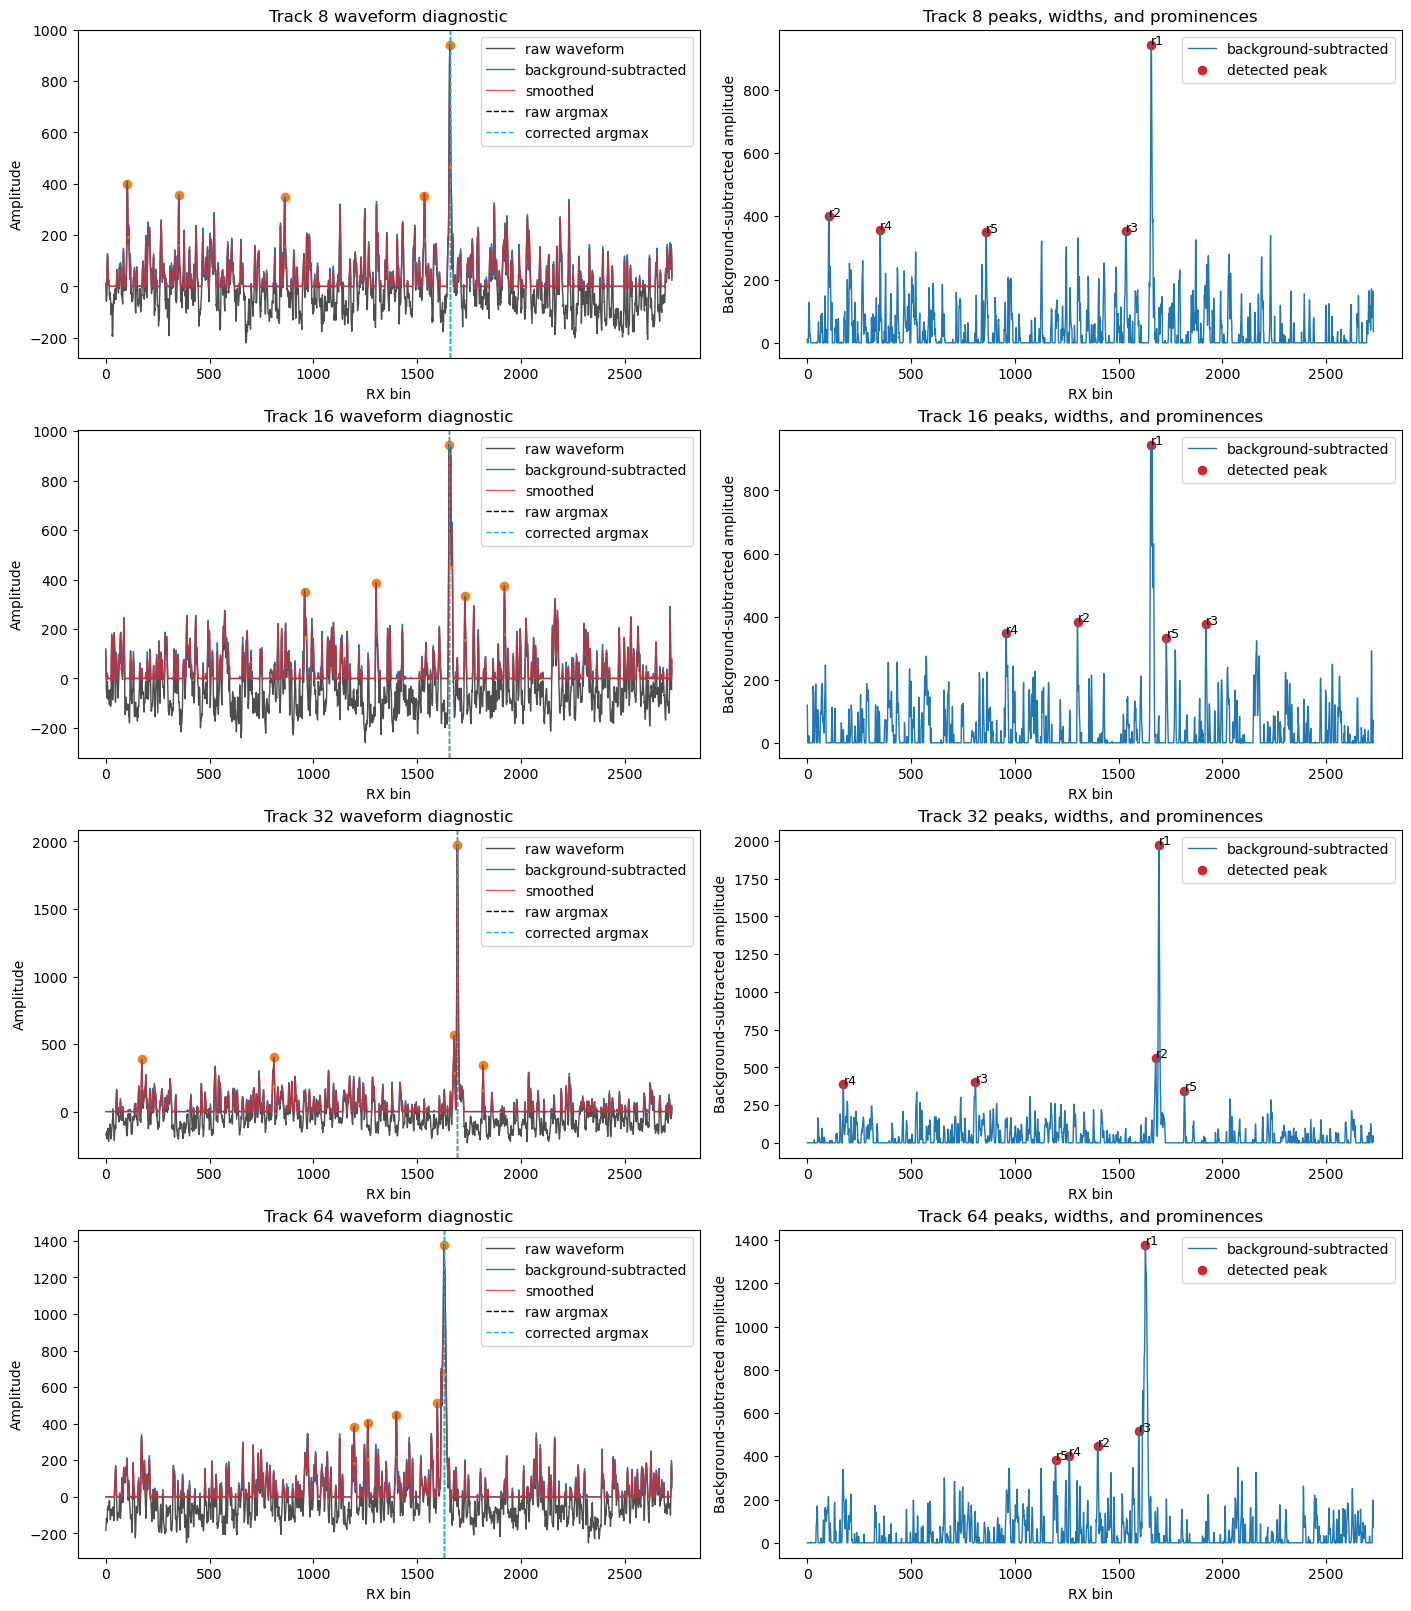

In [5]:
n_rows = len(SELECTED_TRACKS_FOR_WAVEFORMS)
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows), constrained_layout=True, sharex=False)
axes = np.atleast_2d(axes)

for row_idx, track_num in enumerate(SELECTED_TRACKS_FOR_WAVEFORMS):
    detail = selected_waveform_details[track_num]
    prepared = detail["prepared"]
    components = detail["components"]
    raw = prepared["raw"]
    corrected = prepared["processed"]
    smoothed = prepared["smoothed"]
    raw_bin, _ = safe_argmax_bin(raw)
    corrected_bin, _ = safe_argmax_bin(corrected)

    ax = axes[row_idx, 0]
    ax.plot(raw, color="0.3", linewidth=1.0, label="raw waveform")
    ax.plot(corrected, color="tab:blue", linewidth=1.0, label="background-subtracted")
    ax.plot(smoothed, color="tab:red", linewidth=1.0, alpha=0.8, label="smoothed")
    ax.axvline(raw_bin, color="black", linestyle="--", linewidth=1.0, label="raw argmax")
    ax.axvline(corrected_bin, color="tab:cyan", linestyle="--", linewidth=1.0, label="corrected argmax")
    for comp in components:
        ax.scatter(comp["peak_bin"], comp["amplitude_processed"], s=35, color="tab:orange")
        ax.hlines(comp["width_height"], comp["left_ips"], comp["right_ips"], color="tab:orange", linewidth=2.0)
    ax.set_title(f"Track {track_num} waveform diagnostic")
    ax.set_xlabel("RX bin")
    ax.set_ylabel("Amplitude")
    ax.legend(loc="upper right")

    ax = axes[row_idx, 1]
    ax.plot(corrected, color="tab:blue", linewidth=1.0, label="background-subtracted")
    for comp in components:
        ax.scatter(comp["peak_bin"], comp["amplitude_processed"], s=35, color="tab:red", label="detected peak" if comp["rank_by_prominence"] == 1 else None)
        ax.text(comp["peak_bin"], comp["amplitude_processed"], f"r{comp['rank_by_prominence']}", fontsize=9)
    ax.set_title(f"Track {track_num} peaks, widths, and prominences")
    ax.set_xlabel("RX bin")
    ax.set_ylabel("Background-subtracted amplitude")
    ax.legend(loc="upper right")

plt.show()

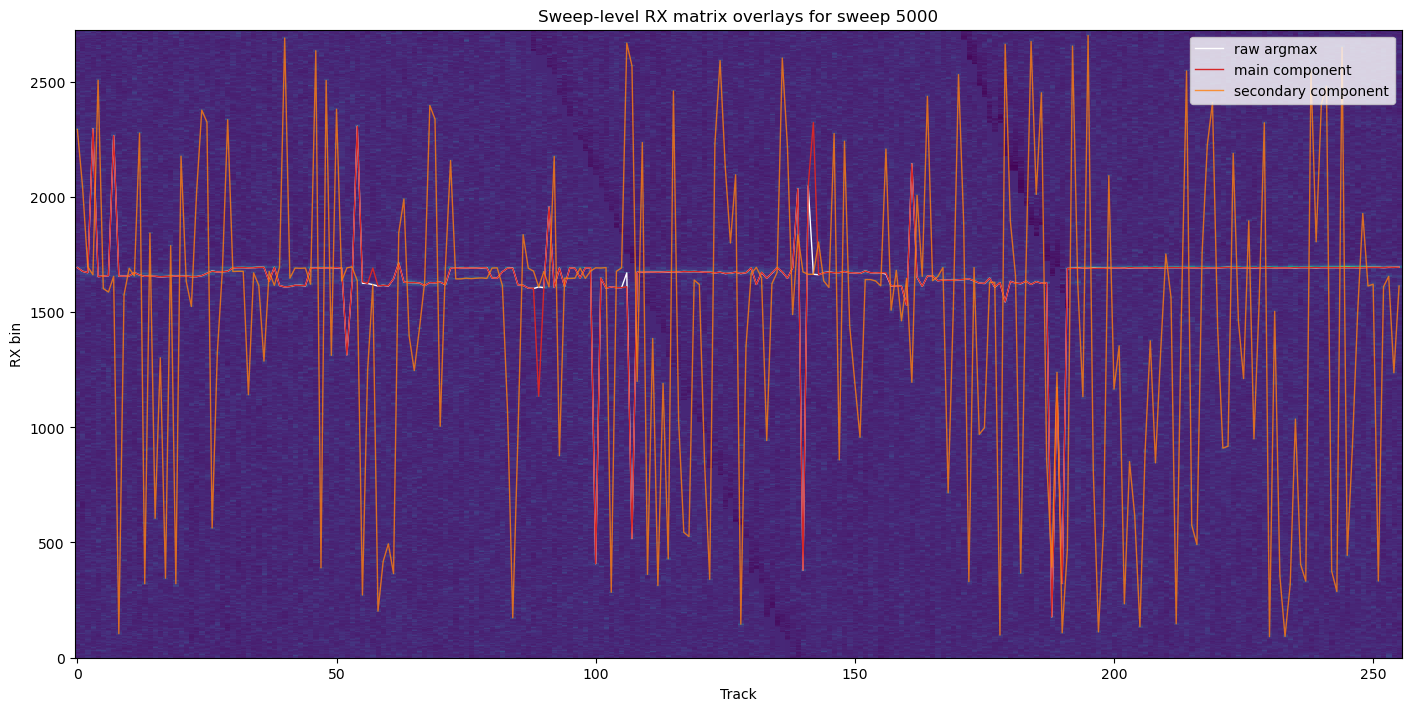

In [6]:
summary_rows = []
main_bins = np.full(info.n_tracks, np.nan, dtype=np.float64)
secondary_bins = np.full(info.n_tracks, np.nan, dtype=np.float64)

for track_num in range(info.n_tracks):
    pulse_index = int(info.record_index_grid[SWEEP_FOR_PLOTTING, track_num])
    cfg = dict(DETECTION_CONFIG)
    cfg["refh_thres"] = float(fields["refh_thres"][pulse_index])
    components = detect_components_1d(
        y_raw=rx_matrix[track_num].astype(np.float64),
        bg_mean=float(fields["bg_mean"][pulse_index]),
        bg_std=float(fields["bg_std"][pulse_index]),
        config=cfg,
    )
    if components:
        main_bins[track_num] = components[0]["peak_bin"]
    if len(components) > 1:
        secondary_bins[track_num] = components[1]["peak_bin"]
    summary_rows.append(
        {
            "track_num": track_num,
            "good_snr": bool(fields["good_snr"][pulse_index]),
            "refh_snr": float(fields["refh_snr"][pulse_index]),
            "n_components": len(components),
            "main_prominence": components[0]["prominence"] if components else np.nan,
            "main_width_bins": components[0]["width_bins"] if components else np.nan,
        }
    )

sweep_component_df = pd.DataFrame(summary_rows)

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
ax.imshow(rx_matrix.T, aspect="auto", origin="lower", cmap="viridis", interpolation="nearest")
ax.plot(np.arange(info.n_tracks), raw_argmax, color="white", linewidth=1.0, label="raw argmax")
ax.plot(np.arange(info.n_tracks), main_bins, color="tab:red", linewidth=1.0, label="main component")
ax.plot(np.arange(info.n_tracks), secondary_bins, color="tab:orange", linewidth=1.0, alpha=0.8, label="secondary component")
ax.set_title(f"Sweep-level RX matrix overlays for sweep {SWEEP_FOR_PLOTTING}")
ax.set_xlabel("Track")
ax.set_ylabel("RX bin")
ax.legend(loc="upper right")
plt.show()

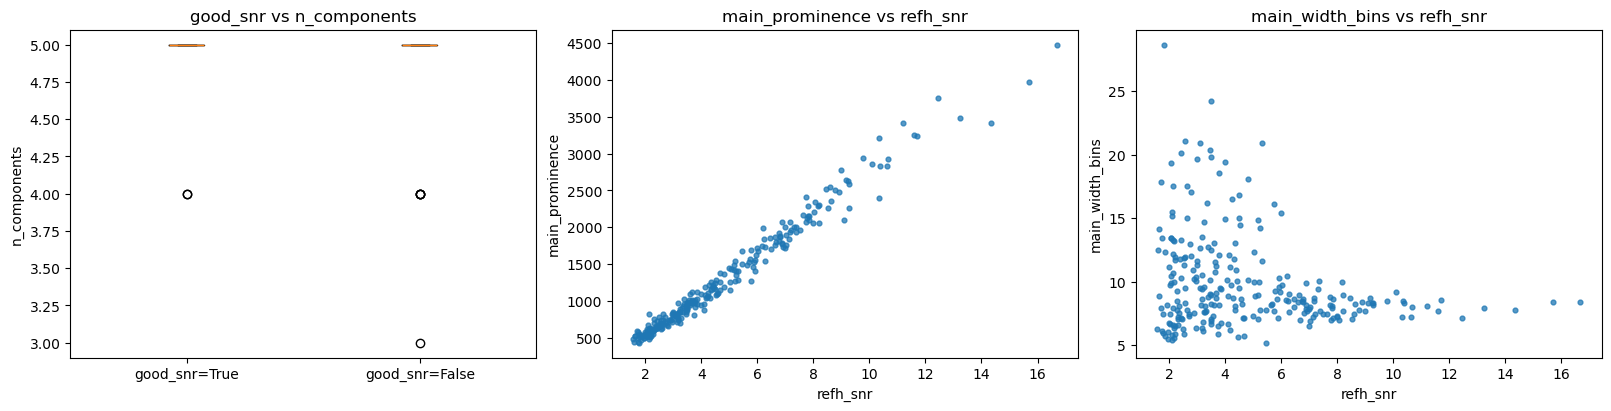

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

data_good = [
    sweep_component_df.loc[sweep_component_df["good_snr"], "n_components"].to_numpy(),
    sweep_component_df.loc[~sweep_component_df["good_snr"], "n_components"].to_numpy(),
]
axes[0].boxplot(data_good, tick_labels=["good_snr=True", "good_snr=False"])
axes[0].set_title("good_snr vs n_components")
axes[0].set_ylabel("n_components")

axes[1].scatter(sweep_component_df["refh_snr"], sweep_component_df["main_prominence"], s=12, alpha=0.75)
axes[1].set_title("main_prominence vs refh_snr")
axes[1].set_xlabel("refh_snr")
axes[1].set_ylabel("main_prominence")

axes[2].scatter(sweep_component_df["refh_snr"], sweep_component_df["main_width_bins"], s=12, alpha=0.75)
axes[2].set_title("main_width_bins vs refh_snr")
axes[2].set_xlabel("refh_snr")
axes[2].set_ylabel("main_width_bins")
plt.show()